4. Go to the PEER Strong Motion Database (NGA-West2: http://ngawest2.berkeley.edu/) 
and download the acceleration time history: FRE000 component, Fremont-Mission San 
Jose station, 1989, Mw6.9 Loma Prieta, California, earthquake (i.e., the same ground 
motion used in homework #3). Using this time history, compute PGA (g), PGV (cm/sec), 
PGD (cm), Arias Intensity, CAV and the duration of significant strong motion using both 
the bracketed duration procedure and 5-95% Husid plot. Discuss the results.  

In [1]:
import numpy as np
from obspy import Trace, Stream
import matplotlib.pyplot as plt
from scipy import signal

In [2]:
# First we must set up the time series properly for Obspy
filename = "RSN762_LOMAP_FRE000.AT2"

# Read header for time step (DT)
with open(filename, "r") as f:
    lines = f.readlines()
    dt = 0.005 # found in file
    data_text = " ".join(lines[4:]) # Extract all text from line 4 onwards (skipping the 4 header lines)

# Make 1D array, ignoring row structure from file
data_g = np.fromstring(data_text, sep=" ")

# Wrap into ObsPy Trace
tr = Trace(data=data_g)
tr.stats.delta = dt
tr.stats.network = "PEER"
tr.stats.station = "FRE"
tr.stats.channel = "000"

st = Stream(traces=[tr])

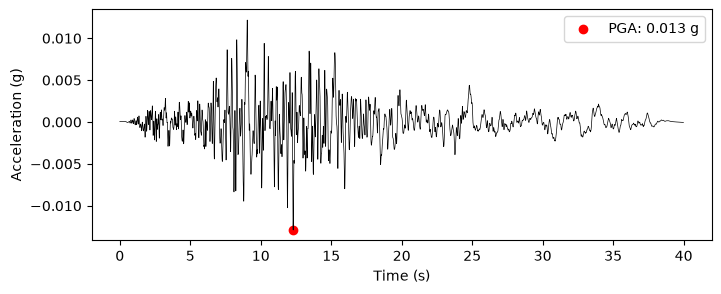

In [3]:
# Computing PGA
pga = np.max(np.abs(st[0].data))/9.81
pga_index = np.argmax(np.abs(st[0].data))
pga_time = pga_index * st[0].stats.delta

plt.figure(figsize=(8,3))
data = [st[0].times(), st[0].data/9.81]
plt.scatter(pga_time, st[0].data[pga_index]/9.81, color="red", marker="o", label=f"PGA: {pga:.3f} g")
plt.plot(data[0], data[1], color='black', linewidth=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")

plt.legend()
plt.show()

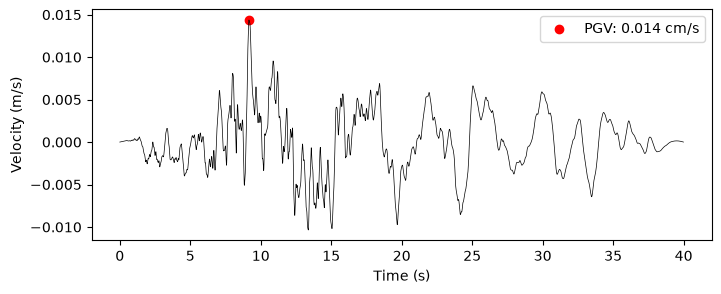

In [6]:
# Computing PGV
st_vel = st.copy()
st_vel.integrate(method="cumtrapz")

pgv = np.max(np.abs(st_vel[0].data))
pgv_index = np.argmax(np.abs(st_vel[0].data))
pgv_time = pgv_index * st_vel[0].stats.delta

plt.figure(figsize=(8,3))
data = [st_vel[0].times(), st_vel[0].data]
plt.scatter(pgv_time, st_vel[0].data[pgv_index], color="red", marker="o", label=f"PGV: {pgv:.3f} cm/s")
plt.plot(data[0], data[1], color='black', linewidth=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")

plt.legend()
plt.show()

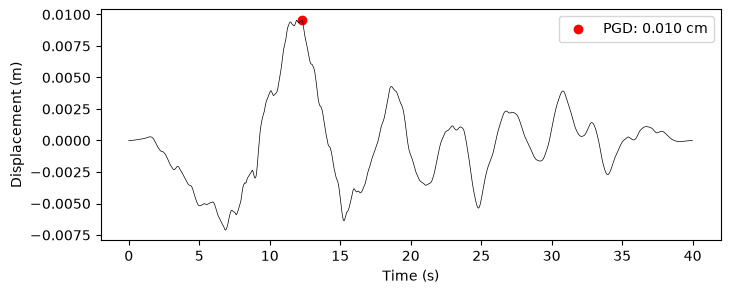

In [7]:
# Computing PGD
st_disp = st_vel.copy()
st_disp.integrate()

pgd = np.max(np.abs(st_disp[0].data))
pgd_index = np.argmax(np.abs(st_disp[0].data))
pgd_time = pgd_index * st_disp[0].stats.delta

plt.figure(figsize=(8,3))
data = [st_disp[0].times(), st_disp[0].data]
plt.scatter(pgd_time, st_disp[0].data[pgd_index], color="red", marker="o", label=f"PGD: {pgd:.3f} cm")
plt.plot(data[0], data[1], color='black', linewidth=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")

plt.legend()
plt.show()

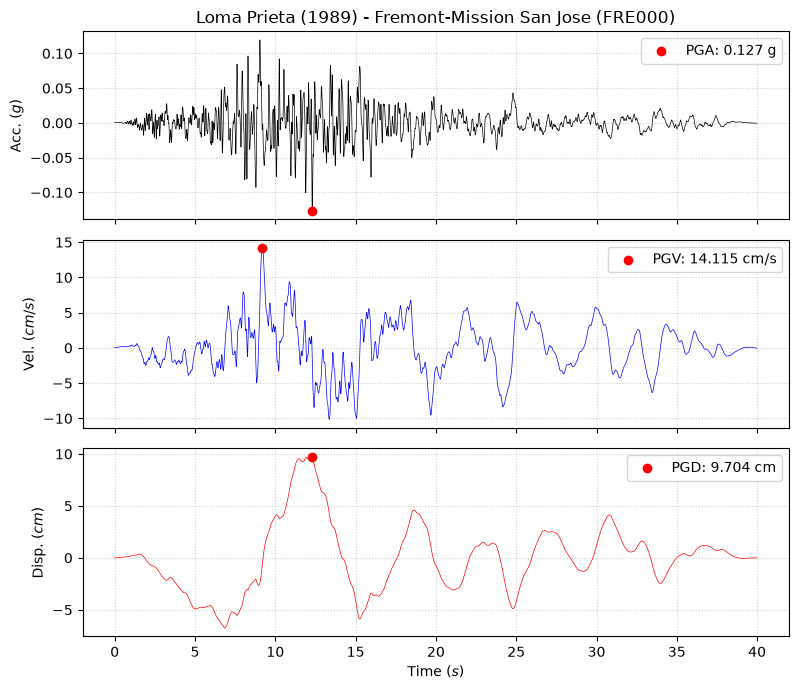

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# Acceleration (g) - using 980.665 cm/s^2 conversion factor
acc_g = st[0].data
acc_cms2 = acc_g * 980.665

pga_index = np.argmax(np.abs(acc_g))
pga_time = acc_time = st[0].times()[pga_index]
pga_val = np.abs(acc_g[pga_index])

# Velocity (cm/s)
st_vel = st.copy()
st_vel[0].data = acc_cms2
st_vel.integrate(method="cumtrapz")
st_vel.detrend("linear")

pgv_index = np.argmax(np.abs(st_vel[0].data))
pgv_time = st_vel[0].times()[pgv_index]
pgv_val = np.abs(st_vel[0].data[pgv_index])

# Displacement (cm)
st_disp = st_vel.copy()
st_disp.integrate(method="cumtrapz")

pgd_index = np.argmax(np.abs(st_disp[0].data))
pgd_time = st_disp[0].times()[pgd_index]
pgd_val = np.abs(st_disp[0].data[pgd_index])


fig, axs = plt.subplots(3, 1, figsize=(8, 7), sharex=True)

axs[0].plot(st[0].times(), acc_g, color='black', linewidth=0.5)
axs[0].scatter(pga_time, acc_g[pga_index], color="red", zorder=5, label=f"PGA: {pga_val:.3f} g")
axs[0].set_ylabel("Acc. ($g$)")
axs[0].set_title("Loma Prieta (1989) - Fremont-Mission San Jose (FRE000)")
axs[0].legend(loc="upper right")
axs[0].grid(True, linestyle=":", alpha=0.6)

axs[1].plot(st_vel[0].times(), st_vel[0].data, color='blue', linewidth=0.5)
axs[1].scatter(pgv_time, st_vel[0].data[pgv_index], color="red", zorder=5, label=f"PGV: {pgv_val:.3f} cm/s")
axs[1].set_ylabel("Vel. (${cm/s}$)")
axs[1].legend(loc="upper right")
axs[1].grid(True, linestyle=":", alpha=0.6)

axs[2].plot(st_disp[0].times(), st_disp[0].data, color='red', linewidth=0.5)
axs[2].scatter(pgd_time, st_disp[0].data[pgd_index], color="red", zorder=5, label=f"PGD: {pgd_val:.3f} cm")
axs[2].set_ylabel("Disp. (${cm}$)")
axs[2].set_xlabel("Time (${s}$)")
axs[2].legend(loc="upper right")
axs[2].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

According to Chapter 4 of Seismic Hazards Analysis (Baker et al.) we can define Arias Intensity (AI) and Cumulative Absolute Velocity (CAV) the following way: 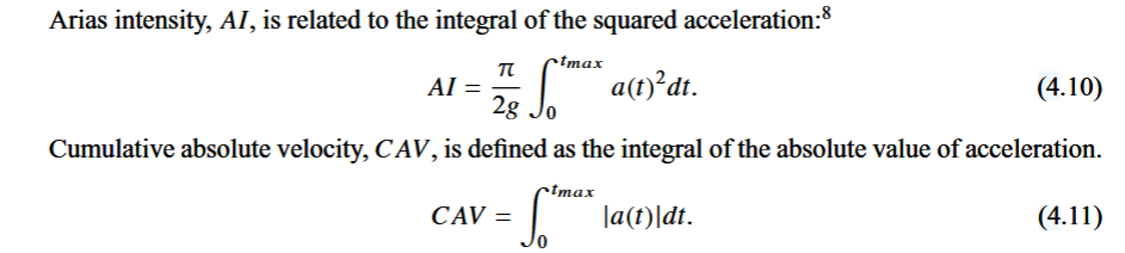

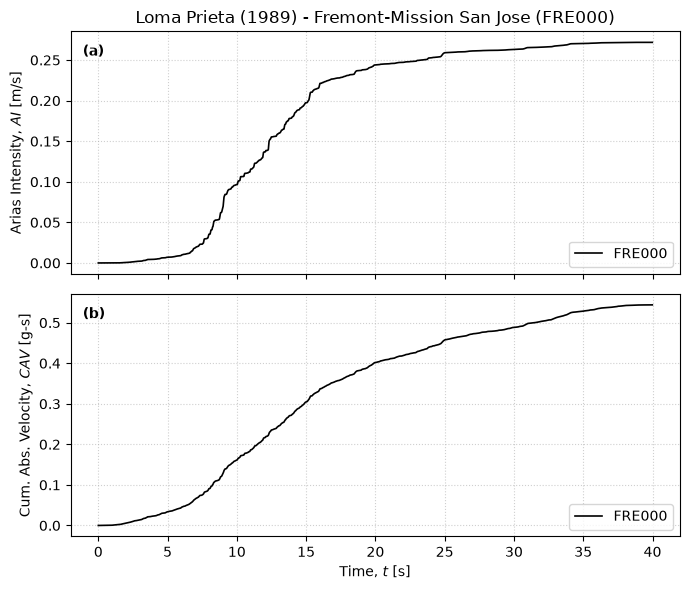

In [ ]:
# Define constants
time = st[0].times()

# Acceleration
acc_g = st[0].data #in g
acc_ms2 = acc_g * 9.80665 # in m/s^2

# Arias Intensity Ia(t) = (pi / (2 * g)) * integral(a(t)^2 dt) in m/s
ai_profile = (np.pi / (2.0 * 9.80665)) * np.cumsum(acc_ms2**2) * dt

# Cumulative Absolute Velocity CAV = integral(|a(t)| dt) with a(t) in g
cav_profile = np.cumsum(np.abs(acc_g)) * dt

fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

axs[0].plot(time, ai_profile, color="black", linewidth=1.2, label="FRE000")
axs[0].set_ylabel("Arias Intensity, $AI$ [m/s]")
axs[0].text(0.02, 0.90, "(a)", transform=axs[0].transAxes, fontweight="bold")
axs[0].grid(True, linestyle=":", alpha=0.6)
axs[0].legend(loc="lower right")
axs[0].set_title("Loma Prieta (1989) - Fremont-Mission San Jose (FRE000)")

axs[1].plot(time, cav_profile, color="black", linewidth=1.2, label="FRE000")
axs[1].set_ylabel("Cum. Abs. Velocity, $CAV$ [g-s]")
axs[1].set_xlabel("Time, $t$ [s]")
axs[1].text(0.02, 0.90, "(b)", transform=axs[1].transAxes, fontweight="bold")
axs[1].grid(True, linestyle=":", alpha=0.6)
axs[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

Bracketed duration is defined as: 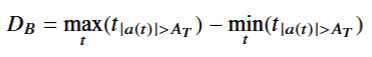 where an acceleration treshold ($A_t$) is selected. In this case a standard engineering treshold selected has been 0.05g. This is because shaking below 0.05g is often assumed to cause negligable strutural damage or a linear-elastic repsonse.

On the other hand, significant duration does not requiere a selectrion of a treshold acceleration. The energy contained in the ground-motion time series is proportional to the cumulative seaures acceleration (AI), therefore if we normalize the arias intensity plot 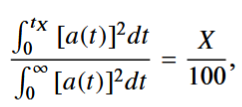 the significant duration can be defined as: 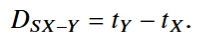, where 5–95% is known as the significant duration, DS5−95.

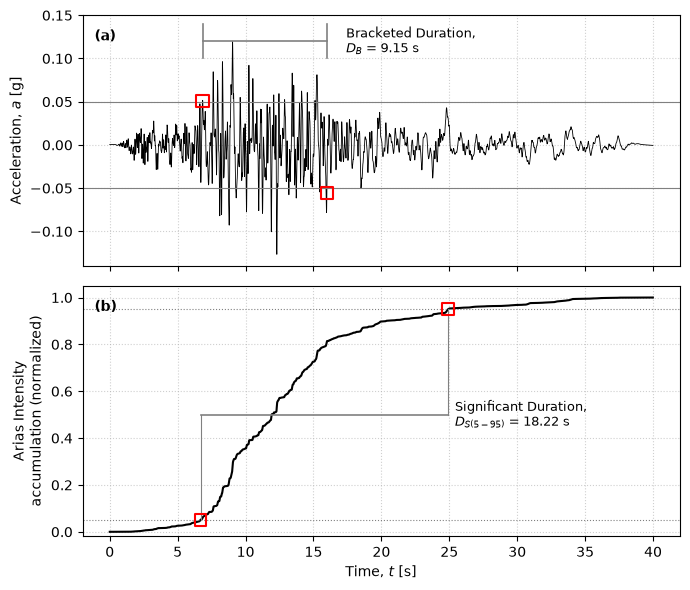

In [ ]:
# Bracketed Duration (A_T = 0.05 g) 
A_T = 0.05 #AT should be specified based on the system being analyzed 
exceed_indices = np.where(np.abs(acc_g) >= A_T)[0]

t_first = time[exceed_indices[0]]
t_last = time[exceed_indices[-1]]
D_B = t_last - t_first

# ignificant Duration (D_5-95) using existing ai_profile 
AI_norm = ai_profile / ai_profile[-1]  # Normalize existing AI array to 1.0

idx_5 = np.where(AI_norm >= 0.05)[0][0]
idx_95 = np.where(AI_norm >= 0.95)[0][0]

t_5 = time[idx_5]
t_95 = time[idx_95]
D_5_95 = t_95 - t_5

fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

axs[0].plot(time, acc_g, color="black", linewidth=0.6)
axs[0].axhline(A_T, color="gray", linestyle="-", linewidth=0.8)
axs[0].axhline(-A_T, color="gray", linestyle="-", linewidth=0.8)

axs[0].scatter(
    [t_first, t_last],
    [acc_g[exceed_indices[0]], acc_g[exceed_indices[-1]]],
    marker="s", s=80, facecolors="none", edgecolors="red", linewidth=1.5, zorder=5
)

axs[0].plot([t_first, t_last], [0.12, 0.12], color="gray", linewidth=1.2)
axs[0].plot([t_first, t_first], [0.10, 0.14], color="gray", linewidth=1.2)
axs[0].plot([t_last, t_last], [0.10, 0.14], color="gray", linewidth=1.2)
axs[0].text((t_first + t_last) / 1.35 + 0.5, 0.12, f"Bracketed Duration,\n$D_B$ = {D_B:.2f} s", fontsize=9, va="center")

axs[0].set_ylabel("Acceleration, $a$ [g]")
axs[0].text(0.02, 0.90, "(a)", transform=axs[0].transAxes, fontweight="bold")
axs[0].set_ylim(-0.14, 0.15)
axs[0].grid(True, linestyle=":", alpha=0.6)

axs[1].plot(time, AI_norm, color="black", linewidth=1.5)
axs[1].axhline(0.05, color="gray", linestyle=":", linewidth=0.8)
axs[1].axhline(0.95, color="gray", linestyle=":", linewidth=0.8)

axs[1].scatter([t_5, t_95], [0.05, 0.95], marker="s", s=70, facecolors="none", edgecolors="red", linewidth=1.5, zorder=5)

axs[1].plot([t_5, t_5], [0.05, 0.50], color="gray", linestyle="-", linewidth=0.8)
axs[1].plot([t_95, t_95], [0.95, 0.50], color="gray", linestyle="-", linewidth=0.8)
axs[1].plot([t_5, t_95], [0.50, 0.50], color="gray", linewidth=1.2)
axs[1].text(t_95 + 0.5, 0.45, f"Significant Duration,\n$D_{{S(5-95)}}$ = {D_5_95:.2f} s", color="Black", fontsize=9)

axs[1].set_ylabel("Arias Intensity\naccumulation (normalized)")
axs[1].set_xlabel("Time, $t$ [s]")
axs[1].text(0.02, 0.90, "(b)", transform=axs[1].transAxes, fontweight="bold")
axs[1].set_ylim(-0.02, 1.05)
axs[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()